In [47]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
%autoreload 2

In [49]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy')
import fp_solvers as fps
import langevin_sindy as lg
import timecorr as tc
import pplane
import sympy
import scipy as sc
import torch
from stochastic_sim import stochastic_sim_EM

In [96]:
def f(x1,x2):
    return np.array([(x1 + 5)*(x2 - 4), (x2 + 2)*(x1 - 3)])

def f1_true(x1,x2):
    return (x1 + 5)*(x2 - 4)

def f2_true(x1,x2):
    return (x2 + 2)*(x1 - 3)

def sigma(x1,x2):
    return np.array([0.5*x1 + 0.01,0.075*x2 + 0.01])

def a(x1,x2):
    return 0.5*sigma(x1,x2)**2

In [97]:
bins = np.load('../outputs/bins_test.npy',allow_pickle=True)

Nx = len(bins[0])-1
Ny = len(bins[1])-1
dx = [(bins[0][1]-bins[0][0]),(bins[1][1]-bins[1][0])]
centers = [0.5*(bins[0][1:]+bins[0][:-1]),0.5*(bins[1][1:]+bins[1][:-1])]

X1,X2=np.meshgrid(centers[0],centers[1])

In [98]:
f_true = f(X1,X2)
a_true = a(X1,X2)

Fixed points:
  • Stable node at x = (-5.000,-2.000)
  • Saddle point at x = (3.000,4.000)


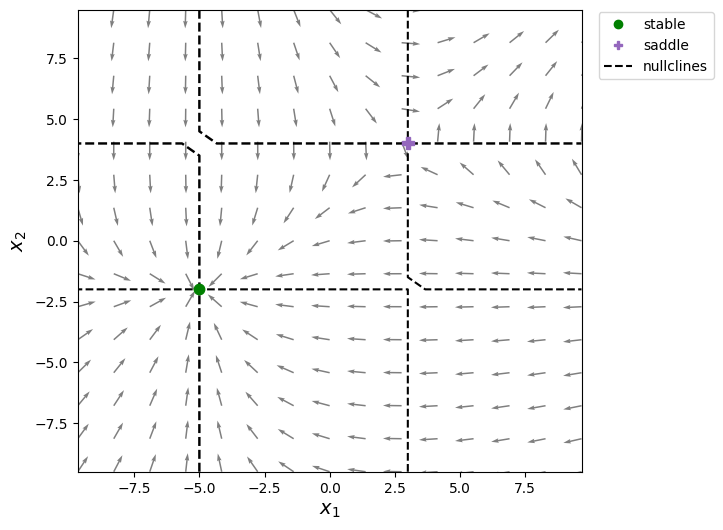

In [99]:
fig = pplane.plot_portrait(f1_true,f2_true,centers[0],centers[1])

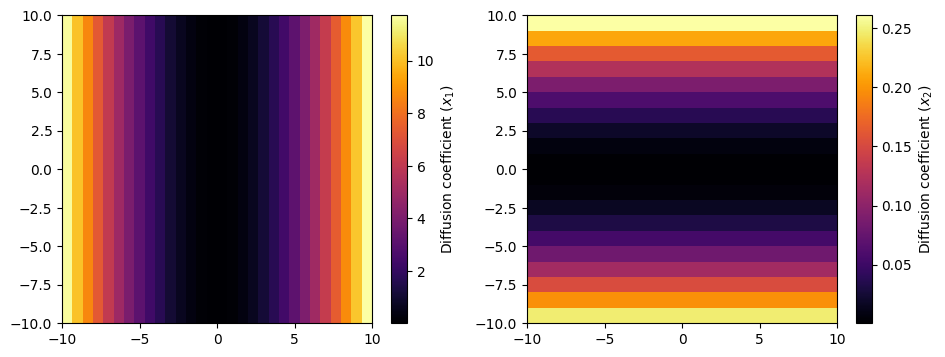

In [54]:
fig,ax = plt.subplots(1,2,figsize=(11,4))
im0=ax[0].pcolormesh(X1,X2,a_true[0],cmap='inferno')
fig.colorbar(im0, ax=ax[0], label='Diffusion coefficient ($x_1$)')
im1 = ax[1].pcolormesh(X1,X2,a_true[1],cmap='inferno')
fig.colorbar(im1, ax=ax[1], label='Diffusion coefficient ($x_2$)')

In [55]:
fp = fps.SteadyFP((Nx,Ny), dx)
p_fit_true = fp.solve(np.swapaxes(f_true,1,2),np.swapaxes(a_true,1,2))
p_fit_true[p_fit_true<0] = 0
p_fit_true = p_fit_true/(np.sum(p_fit_true)*dx[0]*dx[1])

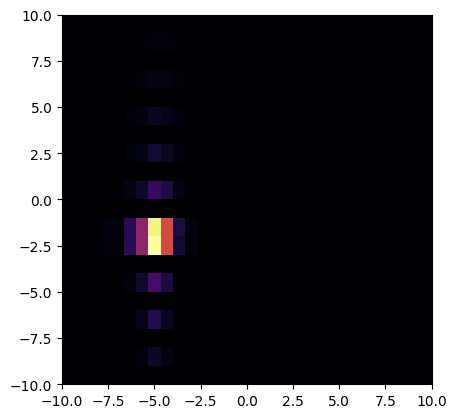

In [56]:
plt.imshow(p_fit_true.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

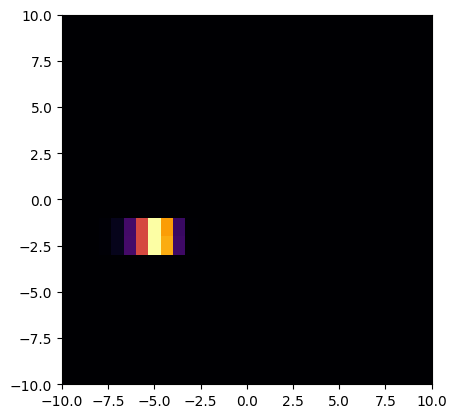

In [57]:
p_hist = np.load('../outputs/p_hist_test.npy')
plt.imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

In [58]:
tc.kl_divergence(p_hist,p_fit_true,dx,tol=tol)

0.4463589799670923

Next: pass data into Langevin SINDy 2D, debug that code 

In [59]:
## Kramers-Moyal average
f_KM = np.load('../outputs/KM_drift_test.npy')
a_KM = np.load('../outputs/KM_diff_test.npy')
f_err = np.load('../outputs/KM_drift_err_test.npy')
a_err = np.load('../outputs/KM_diff_err_test.npy')

x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')

nf=2
ns=1
f_expr = np.tile(np.array([(x1**k)*(x2**(m-k)) for m in range(nf+1) for k in range(m+1)]),2)  # Polynomial library for drift
s_expr = np.tile(np.array([(x1**k)*(x2**(m-k)) for m in range(ns+1) for k in range(m+1)]),2)  # Polynomial library for diffusion

Load outputs from `test_lgs_2d.py`

In [60]:
Xi = np.load('../outputs/coeffs_test.npy')
V = np.load('../outputs/cost_test.npy')

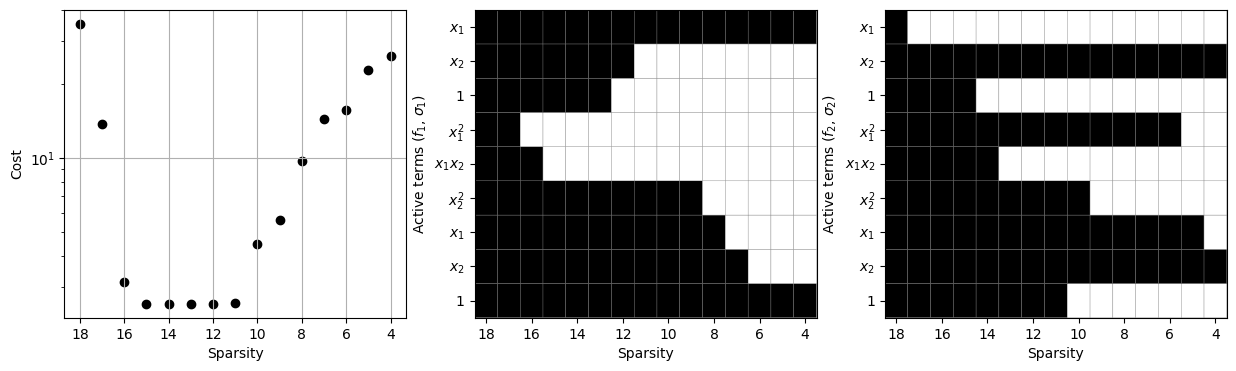

In [61]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
ndim = 2
plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(0,n_terms-(2*ndim-1),2))
plt.gca().set_xticklabels(np.arange(n_terms, (2*ndim-1), -2))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
plt.gca().set_yscale('log')
plt.grid()

active_1 = np.concatenate((active[:len(f_expr)//2], active[len(f_expr):len(f_expr)+len(s_expr)//2]))
labels_1 = np.concatenate((labels[:len(f_expr)//2], labels[len(f_expr):len(f_expr)+len(s_expr)//2]))
plt.subplot(132)
plt.pcolor(active_1, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_1.shape[0]))
plt.gca().set_yticklabels(labels_1)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-(2*ndim-1),2))
plt.gca().set_xticklabels(np.arange(n_terms, (2*ndim-1), -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms ($f_1$, $\sigma_1$)')


active_2 = np.concatenate((active[len(f_expr)//2:len(f_expr)], active[len(f_expr)+len(s_expr)//2:]))
labels_2 = np.concatenate((labels[len(f_expr)//2:len(f_expr)], labels[len(f_expr)+len(s_expr)//2:]))
plt.subplot(133)
plt.pcolor(active_2, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_2.shape[0]))
plt.gca().set_yticklabels(labels_2)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-(2*ndim-1),2))
plt.gca().set_xticklabels(np.arange(n_terms, 2*ndim-1, -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms ($f_2$, $\sigma_2$)')

plt.show()

In [73]:
# Select model with the fewest terms before the cost function spikes
n_terms = 11
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("SINDy expression (drift): ")
print("     f_1(x1,x2) = ", sympy.Matrix(np.round(Xi_f[:len(f_expr)//2],4)).dot(sympy.Matrix(f_expr[:len(f_expr)//2])))
print("     f_2(x1,x2) = ", sympy.Matrix(np.round(Xi_f[len(f_expr)//2:],4)).dot(sympy.Matrix(f_expr[len(f_expr)//2:])))
print("SINDy expression (diffusion): ")
print("     sigma_1(x1,x2) = ", sympy.Matrix(np.round(Xi_s[:len(s_expr)//2],4)).dot(sympy.Matrix(s_expr[:len(s_expr)//2])))
print("     sigma_2(x1,x2) = ", sympy.Matrix(np.round(Xi_s[len(s_expr)//2:],4)).dot(sympy.Matrix(s_expr[len(s_expr)//2:])))

Optimal sparsity:  11
Cost at optimal sparsity:  2.554805487415116
SINDy expression (drift): 
     f_1(x1,x2) =  -3.2386*x1 + 0.6472*x2**2 + 3.9672*x2 - 18.7181
     f_2(x1,x2) =  0.322*x1**2 + 3.6116*x1 + 0.5232*x2**2 - 4.6004*x2 - 4.6035
SINDy expression (diffusion): 
     sigma_1(x1,x2) =  0.4345*x1 + 0.1777*x2 - 0.1299
     sigma_2(x1,x2) =  -0.0013*x2


In [74]:
x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')
f1 = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f[:len(f_expr)//2]).dot(sympy.Matrix(f_expr[:len(f_expr)//2])))
f2 = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f[len(f_expr)//2:]).dot(sympy.Matrix(f_expr[len(f_expr)//2:])))

a1 = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s[:len(s_expr)//2]).dot(sympy.Matrix(s_expr[:len(s_expr)//2]))**2)
a2 = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s[len(s_expr)//2:]).dot(sympy.Matrix(s_expr[len(s_expr)//2:]))**2)

def f_sindy(X1,X2):
    F1 = f1(X1,X2)
    F2 = f2(X1,X2)
    if np.isscalar(F1):
        F1 = F1 + 0*X1
    if np.isscalar(F2):
        F2 = F2 + 0*X1
    return np.array([F1,F2])

def a_sindy(X1,X2):
    A1 = a1(X1,X2)
    A2 = a2(X1,X2)
    if np.isscalar(A1):
        A1 = A1 + 0*X1
    if np.isscalar(A2):
        A2 = A2 + 0*X1
    return np.array([A1,A2])

In [75]:
f_vals = f_sindy(X1,X2)
a_vals = a_sindy(X1,X2)

In [85]:
# Compare PDFs: empirical vs Fokker-Planck solution with model
fp = fps.SteadyFP((Nx,Ny), dx)
p_fit = fp.solve(np.swapaxes(f_vals,1,2),np.swapaxes(a_vals,1,2))
p_fit[p_fit<0] = 0
p_fit = p_fit/(np.sum(np.sum(p_fit,axis=0)*dx[0])*dx[1])
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

KL divergence (LINDy model): 8.33352


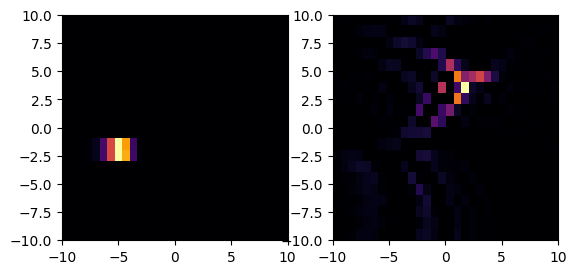

In [86]:
# PDF of states
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(p_fit.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

In [87]:
stride=5
dt=0.01
afp = fps.AdjFP(centers,ndim=2)
afp.precompute_operator(f_vals.transpose((0,2,1)).reshape((2,Nx*Ny)), a_vals.transpose((0,2,1)).reshape((2,Nx*Ny)))
f_tau, a_tau = afp.solve(stride*dt,d=[0,1])

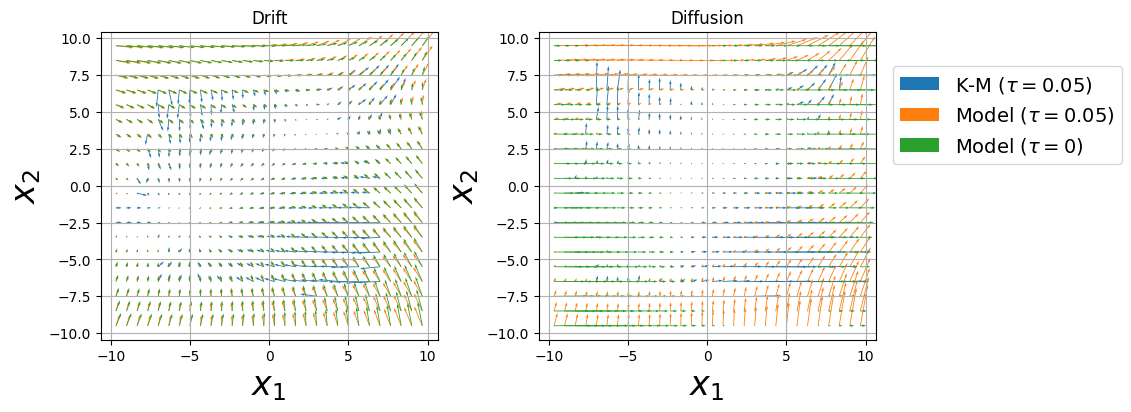

In [88]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(X1,X2, f_KM[:,:,0].T,f_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_tau[0].reshape((Nx,Ny)).T,f_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_vals[0],f_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(X1,X2, a_KM[:,:,0].T,a_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_tau[0].reshape((Nx,Ny)).T,a_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_vals[0],a_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

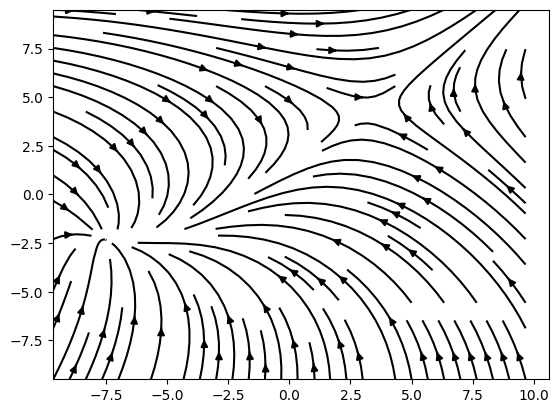

In [89]:
plt.streamplot(X1,X2,f_vals[0],f_vals[1],color='k')

Text(0, 0.5, '$x_2$')

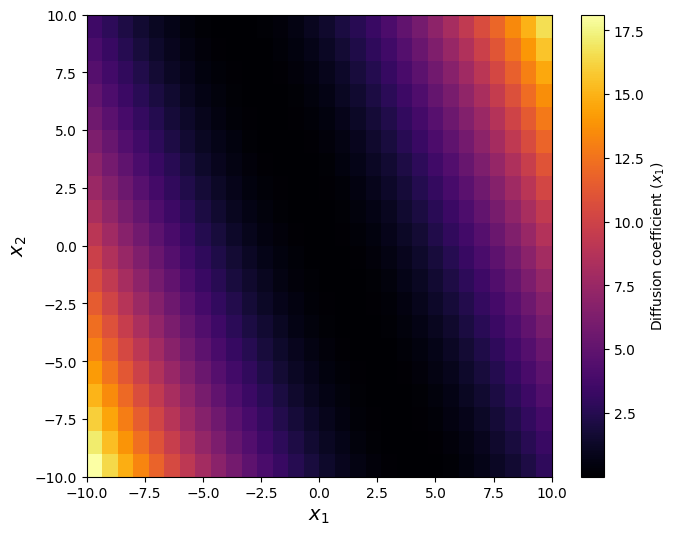

In [81]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[0],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_1$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Text(0, 0.5, '$x_2$')

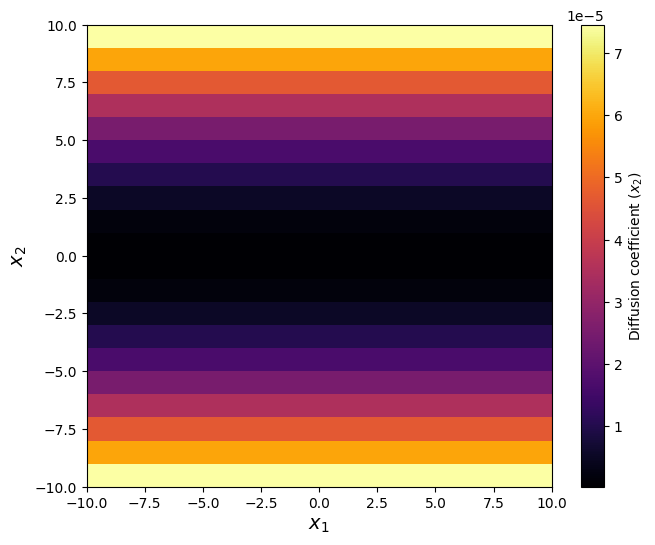

In [82]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[1],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_2$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Fixed points:
  • Saddle point at x = (3.175,4.297)
  • Stable node at x = (-7.547,-2.324)


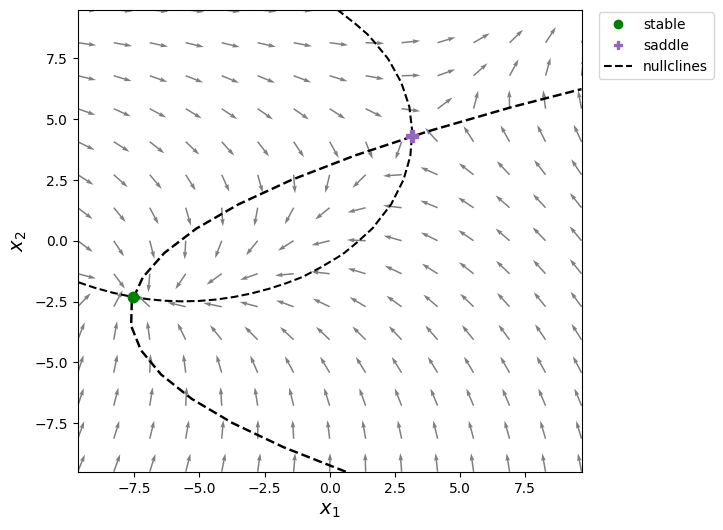

In [83]:
fig = pplane.plot_portrait(f1,f2,centers[0],centers[1])

In [ ]:
inits = np.random.uniform(low = [-7,-7], high = [7,7], size = (1000,2)).T
dt = 0.01
trajs_sindy = stochastic_sim_EM(inits, lambda x: f_sindy(x[0],x[1]), lambda x: np.sqrt(2*a_sindy(x[0],x[1])), dt = dt, n_timepoints = 5000)

stride = 5
X_t_sindy = np.swapaxes(trajs_sindy,0,2)

num_traj = X_t_sindy.shape[0]
num_t = X_t_sindy.shape[1]
num_feats = X_t_sindy.shape[2]

data = []
data_stationary = []
for j in range(num_traj):
    my_idx = []
    idx_stat = []
    for i in range(num_t):
        my_cond = (bins[0][0] <= X_t_sindy[j,i,0] <= bins[0][-1]) and (bins[1][0] <= X_t_sindy[j,i,1] <= bins[1][-1])
        if my_cond:
            my_idx.append(i) 
    if len(my_idx) > 0:
        idx_stat = [i for i in my_idx if i >= num_t-200]
        data.append(X_t_sindy[j,my_idx,:])
    if len(idx_stat) > 0:
        data_stationary.append(X_t_sindy[j,idx_stat,:])

p_hist_sindy = np.histogram2d(np.concatenate(data_stationary)[:,0],np.concatenate(data_stationary)[:,1],bins,density=True)[0]

<lambdifygenerated-17>:2: RuntimeWarning: overflow encountered in square
  return -3.23856284817226*x1 + 0.647222339322864*x2**2 + 3.96715777360375*x2 - 18.7180940643269
<lambdifygenerated-18>:2: RuntimeWarning: overflow encountered in square
  return 0.322028300161761*x1**2 + 3.61158362858422*x1 + 0.523184818613937*x2**2 - 4.60040161251223*x2 - 4.60352958884141
<lambdifygenerated-19>:2: RuntimeWarning: overflow encountered in square
  return 0.094386976251645*(x1 + 0.409067385282849*x2 - 0.298865230419749)**2
<lambdifygenerated-20>:2: RuntimeWarning: overflow encountered in square
  return 8.26594583382357e-7*x2**2
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/stochastic_sim.py:27: RuntimeWarning: invalid value encountered in add
  x = x + drift(x)*dt + np.sqrt(dt)*noise(x)*rng.standard_normal(size=(n_dim,n_traj))
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/stochastic_sim.py:25: RuntimeWarning: invalid value encountered in 

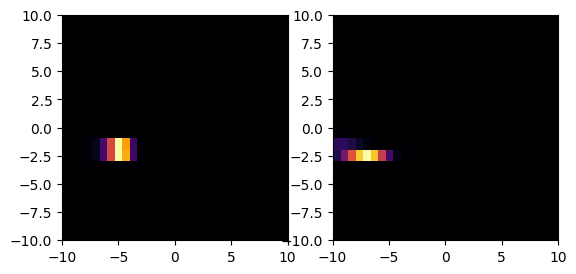

In [94]:
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(p_hist_sindy.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

In [95]:
# Compare PDFs: empirical vs Fokker-Planck solution with model
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_hist_sindy, dx=dx, tol=1e-6)))

KL divergence (LINDy model): 5.35588
